<a href="https://colab.research.google.com/github/Patro331/blood-smear-sickle-cell-classification/blob/main/notebooks/02_feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Smear Sickle Cell Classification
## MSB7215: Machine Learning in Biomedicine
### Notebook 02: HOG Feature Extraction

**Author:** Okidi Patrovas Gabriel | 2025/HD07/26020U
**Institution:** Makerere University, Kampala, Uganda

## Overview

This notebook extracts numerical features from the blood smear
images using Histogram of Oriented Gradients (HOG). HOG captures
the shape and edge information of cells in an image by computing
the distribution of gradient orientations in localised regions.

Since classical machine learning algorithms such as SVM and Random
Forest require a tabular features matrix as input, we cannot feed
raw images directly. HOG feature extraction converts each image
into a fixed-length numerical vector, creating a features matrix
where each row represents one image and each column represents
one HOG feature.

Pipeline:
Raw Image → Resize to 128x128 → Grayscale → HOG → Feature Vector

The choice of 128x128 pixels is justified by the data understanding
notebook which showed significant size variation between classes.
Standardising to this resolution eliminates image dimension as a
spurious discriminating feature.

In [ ]:
# Install and import required libraries
!pip install scikit-image --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import hog
from skimage import color, transform
from skimage.io import imread
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("All libraries imported successfully")

All libraries imported successfully


## 1. Mount Drive and Set Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR     = '/content/drive/MyDrive/sickle-cell-detection'
POSITIVE_DIR = f'{BASE_DIR}/data/raw/positive'
NEGATIVE_DIR = f'{BASE_DIR}/data/raw/negative'
SAVE_DIR     = f'{BASE_DIR}/data/ml_features'
FIG_DIR      = f'{BASE_DIR}/figures'

os.makedirs(SAVE_DIR, exist_ok=True)

pos_images = [f for f in os.listdir(POSITIVE_DIR)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
neg_images = [f for f in os.listdir(NEGATIVE_DIR)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"Positive images: {len(pos_images)}")
print(f"Negative images: {len(neg_images)}")
print(f"Total:           {len(pos_images) + len(neg_images)}")

Mounted at /content/drive
Positive images: 422
Negative images: 511
Total:           933


## 2. HOG Feature Extraction

Histogram of Oriented Gradients (HOG) works by dividing an image
into small cells and computing a histogram of gradient directions
within each cell. These histograms are then normalised across
larger blocks to reduce the effect of lighting variation.

The key parameters used are:

- Image size: 128x128 pixels — standardises all images before extraction
- Orientations: 9 — number of gradient direction bins per cell
- Pixels per cell: 8x8 — size of each local cell
- Cells per block: 2x2 — normalisation block size
- Channel axis: None — HOG applied to grayscale image

Each image produces a single feature vector. All 933 vectors
are stacked into a features matrix X and the corresponding
class labels are stored in a target vector y.

In [ ]:
def extract_hog_features(image_path, image_size=(128, 128)):
    """
    Load an image, resize, convert to grayscale and extract HOG features.

    Parameters
    ----------
    image_path : str
    image_size : tuple — target size for resizing

    Returns
    -------
    numpy array of HOG feature vector
    """
    img = Image.open(image_path).convert('RGB')
    img = img.resize(image_size)
    img_array = np.array(img)

    # Convert to grayscale
    img_gray = color.rgb2gray(img_array)

    # Extract HOG features
    features = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )
    return features

# Test on one image to confirm feature vector length
test_path = os.path.join(POSITIVE_DIR, pos_images[0])
test_features = extract_hog_features(test_path)

print(f"HOG feature vector length: {len(test_features)}")
print(f"Each image produces {len(test_features)} numerical features")
print(f"Feature vector sample (first 10 values):")
print(np.round(test_features[:10], 4))

HOG feature vector length: 8100
Each image produces 8100 numerical features
Feature vector sample (first 10 values):
[0.0661 0.2661 0.3963 0.0583 0.0908 0.0027 0.0232 0.0014 0.0318 0.2571]


## 3. Extract Features for All Images

We now extract HOG features for all 933 images and build the
complete features matrix X and target vector y. This may take
a few minutes depending on the runtime.

In [ ]:
print("Extracting HOG features from all images...")
print("This may take a few minutes...")

X = []
y = []
filenames = []
failed = []

# Extract from positive images
for i, fname in enumerate(pos_images):
    try:
        path     = os.path.join(POSITIVE_DIR, fname)
        features = extract_hog_features(path)
        X.append(features)
        y.append(1)
        filenames.append(fname)
        if (i + 1) % 100 == 0:
            print(f"  Positive: {i+1}/{len(pos_images)} done")
    except Exception as e:
        failed.append(fname)
        print(f"  Failed: {fname} — {e}")

# Extract from negative images
for i, fname in enumerate(neg_images):
    try:
        path     = os.path.join(NEGATIVE_DIR, fname)
        features = extract_hog_features(path)
        X.append(features)
        y.append(0)
        filenames.append(fname)
        if (i + 1) % 100 == 0:
            print(f"  Negative: {i+1}/{len(neg_images)} done")
    except Exception as e:
        failed.append(fname)
        print(f"  Failed: {fname} — {e}")

X = np.array(X)
y = np.array(y)

print(f"\nFeature extraction complete")
print(f"Features matrix shape: {X.shape}")
print(f"Target vector shape:   {y.shape}")
print(f"Failed extractions:    {len(failed)}")
print(f"\nClass distribution in y:")
print(f"  Positive (1): {(y==1).sum()}")
print(f"  Negative (0): {(y==0).sum()}")

Extracting HOG features from all images...
This may take a few minutes...
  Positive: 100/422 done
  Positive: 200/422 done
  Positive: 300/422 done
  Positive: 400/422 done
  Negative: 100/511 done
  Negative: 200/511 done
  Negative: 300/511 done
  Negative: 400/511 done
  Negative: 500/511 done

Feature extraction complete
Features matrix shape: (933, 8100)
Target vector shape:   (933,)
Failed extractions:    0

Class distribution in y:
  Positive (1): 422
  Negative (0): 511


### Observations

HOG features were extracted from all 933 images with no failures.
The resulting features matrix X has shape 933 rows by 8100 columns,
meaning we have 933 samples and 8100 features per sample. The target
vector y contains 422 positive labels and 511 negative labels,
matching the original class distribution. The features matrix is
now ready for preprocessing and model training.

## 4. Visualise HOG Features

We visualise the HOG representation of one positive and one negative
image side by side. This confirms that HOG captures meaningful
structural differences between the two classes.

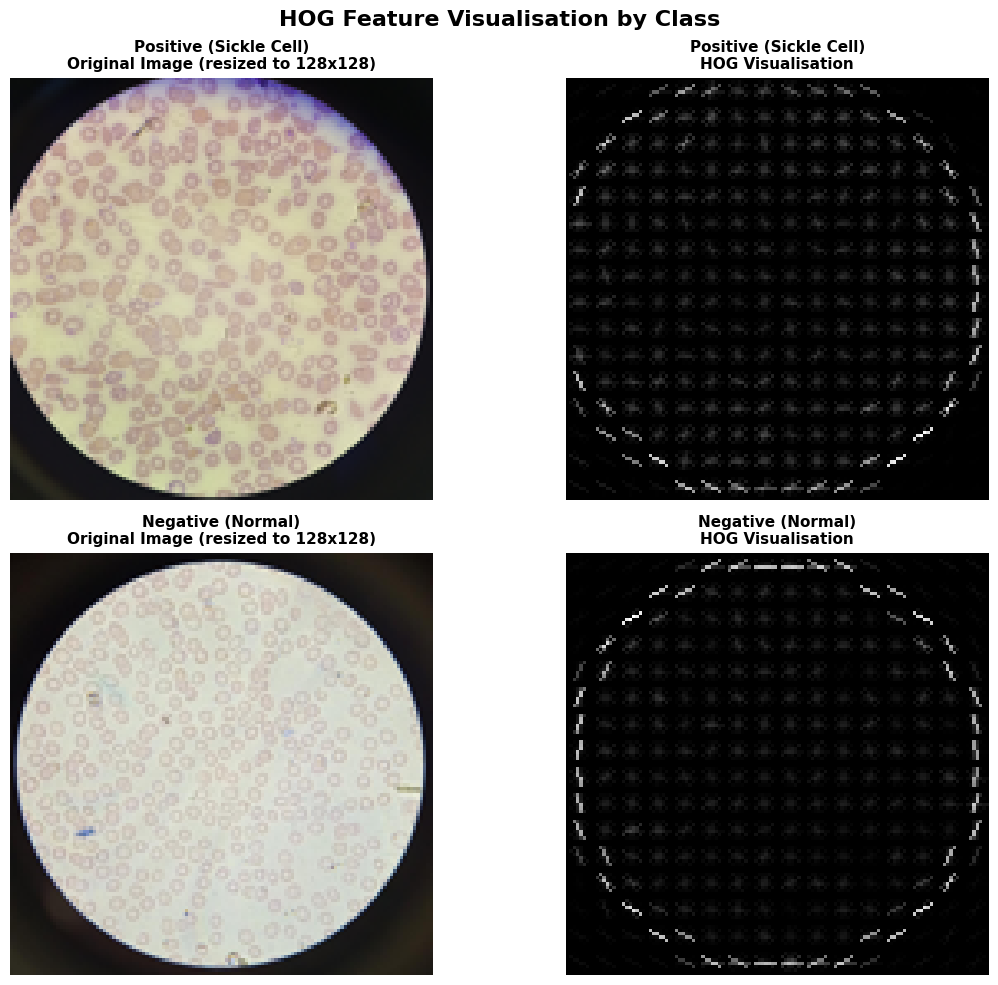

HOG visualisation saved


In [ ]:
from skimage import color as color_module

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('HOG Feature Visualisation by Class',
             fontsize=16, fontweight='bold')

samples = [
    (os.path.join(POSITIVE_DIR, pos_images[0]), 'Positive (Sickle Cell)'),
    (os.path.join(NEGATIVE_DIR, neg_images[0]), 'Negative (Normal)')
]

for i, (img_path, label) in enumerate(samples):
    img       = Image.open(img_path).convert('RGB')
    img       = img.resize((128, 128))
    img_array = np.array(img)
    img_gray  = color_module.rgb2gray(img_array)

    features, hog_image = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True
    )

    axes[i, 0].imshow(img_array)
    axes[i, 0].set_title(f'{label}\nOriginal Image (resized to 128x128)',
                          fontweight='bold', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(hog_image, cmap='gray')
    axes[i, 1].set_title(f'{label}\nHOG Visualisation',
                          fontweight='bold', fontsize=11)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/hog_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("HOG visualisation saved")

### Observations

The HOG visualisation shows how each image is represented after
feature extraction. The bright regions in the HOG images indicate
areas with strong edges and gradients. Both images show strong
activation along the circular microscope border, which is expected
since it creates a sharp edge. The positive image shows more
activity inside the circular field compared to the negative image,
reflecting the irregular elongated cell shapes characteristic of
sickle cell disease. The negative image shows more uniform and
evenly spaced gradient patterns, consistent with the round regular
shape of normal red blood cells.

## 5. Save Features Matrix

We save the extracted features matrix X and target vector y to
Google Drive so they can be loaded directly in the preprocessing
and modelling notebooks without re-running the extraction.

In [ ]:
# Save features matrix and labels
np.save(f'{SAVE_DIR}/X_features.npy', X)
np.save(f'{SAVE_DIR}/y_labels.npy', y)
np.save(f'{SAVE_DIR}/filenames.npy', np.array(filenames))

# Verify saved files
print("Files saved successfully:")
print(f"  X_features.npy — shape: {np.load(f'{SAVE_DIR}/X_features.npy').shape}")
print(f"  y_labels.npy   — shape: {np.load(f'{SAVE_DIR}/y_labels.npy').shape}")
print(f"  filenames.npy  — shape: {np.load(f'{SAVE_DIR}/filenames.npy').shape}")
print(f"\nSave location: {SAVE_DIR}")

print(f"""
FEATURE EXTRACTION SUMMARY
  Total images processed:  933
  Failed extractions:      0
  HOG feature vector size: 8100
  Features matrix shape:   {X.shape}
  Target vector shape:     {y.shape}
  Image size used:         128x128 pixels
  HOG orientations:        9
  Pixels per cell:         8x8
  Cells per block:         2x2
  Block normalisation:     L2-Hys

FEATURE EXTRACTION COMPLETE — Proceed to 03_preprocessing_pipeline.ipynb
""")

Files saved successfully:
  X_features.npy — shape: (933, 8100)
  y_labels.npy   — shape: (933,)
  filenames.npy  — shape: (933,)

Save location: /content/drive/MyDrive/sickle-cell-detection/data/ml_features

FEATURE EXTRACTION SUMMARY
  Total images processed:  933
  Failed extractions:      0
  HOG feature vector size: 8100
  Features matrix shape:   (933, 8100)
  Target vector shape:     (933,)
  Image size used:         128x128 pixels
  HOG orientations:        9
  Pixels per cell:         8x8
  Cells per block:         2x2
  Block normalisation:     L2-Hys

FEATURE EXTRACTION COMPLETE — Proceed to 03_preprocessing_pipeline.ipynb



### Summary

HOG features were successfully extracted from all 933 blood smear
images. Each image was resized to 128x128 pixels, converted to
grayscale, and processed through the HOG algorithm to produce a
feature vector of 8100 values. The features matrix and target
vector have been saved to Google Drive and are ready for use in
the preprocessing and modelling notebooks.